In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/22_열처리.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

## 실습 5. 변화량·변화율 계산과 시각화
급변을 포착하고 이동평균 후 변화량으로 잡음 줄이기

목표
- 변화량과 변화율로 급변을 포착하고 이동평균 후 변화량으로 잡음을 줄이기

단계
- 직전 대비 변화량과 변화율을 각각 구하기
- 앞부분 값을 확인해 첫 값이 비는 이유 이해
- 이동평균을 먼저 낸 뒤 변화량을 구해 잡음이 줄어듦을 확인

예상 결과
- 변화량 앞부분 -0.43·3.07…, 첫 값은 비교 대상이 없어 빈 값

In [2]:
# 파일 불러와 크기와 엔진 목록 확인
df = pd.read_csv("23_전기Panel.csv")
print(df.shape) # (1250, 7)

eng2 = df[df['설비번호'] == 2].copy().sort_values('시퀀스').reset_index(drop=True)

eng2['ma10'] = eng2['컨베이어전류'].rolling(window=10).mean()

eng2['diff'] = eng2['컨베이어전류'].diff()
print('변화량:', eng2['diff'].head(4).round(4).tolist())
# 변화량: [nan, 0.0, 0.0, 0.0]

idx = eng2['diff'].abs().idxmax()
print('최대 변화량:', round(eng2['diff'].abs().max(), 4), '/ 시퀀스:', int(eng2['시퀀스'].iloc[idx]))
# 최대 변화량: 0.2602 / 시퀀스: 136

eng2['ma_diff'] = eng2['ma10'].diff()


(1250, 7)
변화량: [nan, 0.0, 0.0, 0.0]
최대 변화량: 0.2602 / 시퀀스: 136


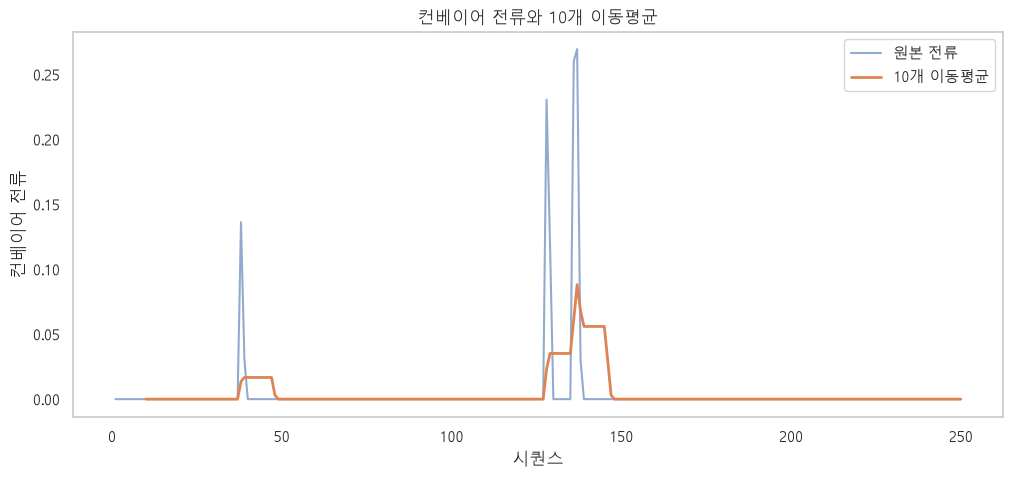

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    eng2["시퀀스"],
    eng2["컨베이어전류"],
    label="원본 전류",
    alpha=0.6
)

plt.plot(
    eng2["시퀀스"],
    eng2["ma10"],
    label="10개 이동평균",
    linewidth=2
)

plt.xlabel("시퀀스")
plt.ylabel("컨베이어 전류")
plt.title("컨베이어 전류와 10개 이동평균")
plt.legend()
plt.grid()

plt.show()

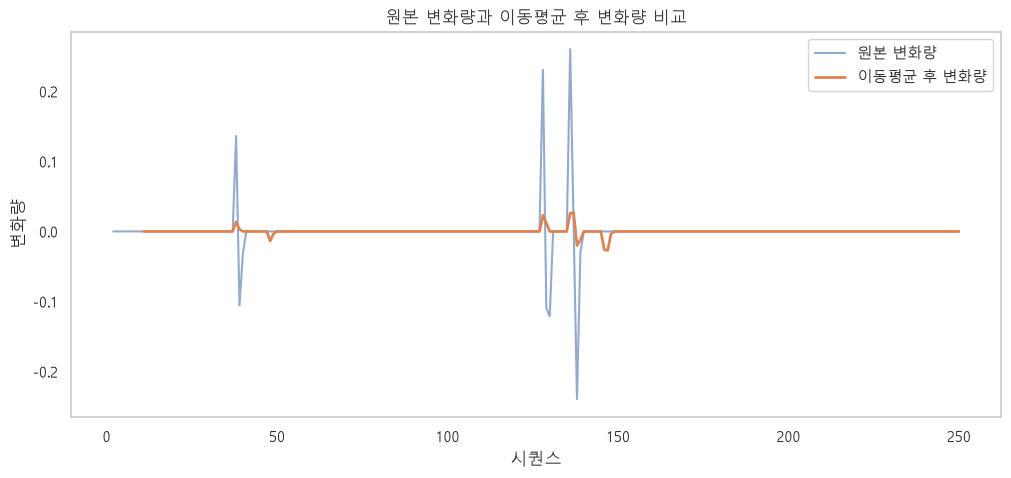

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(
    eng2["시퀀스"],
    eng2["diff"],
    label="원본 변화량",
    alpha=0.6
)

plt.plot(
    eng2["시퀀스"],
    eng2["ma_diff"],
    label="이동평균 후 변화량",
    linewidth=2
)

plt.xlabel("시퀀스")
plt.ylabel("변화량")
plt.title("원본 변화량과 이동평균 후 변화량 비교")
plt.legend()
plt.grid()

plt.show()